# Finding Supernova Neutrinos

To date we have only managed to detect the neutrinos from one supernova, which arrived at Earth on the 23rd February 1987 and is known by the snappy name SN1987A. In this project you will investigate the feasibility of idenitfying supernova neutrino events in a new type of detector a liquid argon time-projection chamber. These detectors give incredibly high-resolution 'images' of the charged-particle tracks produced when a neutrino interacts in the detector.

The data for this mini-project comes in the form of the following files:

| File | Description |
| ----------- | ----------- |
| larImages.npy | A numpy array of 10,000 100x100 pixel images |
| meta.npy | The meta information about the particles in the image |


The images show the energy deposited in the liquid argon detector in a small slice of space and time. The meta information contains the following 64 numbers  for each image. The [PDG code](https://pdg.lbl.gov/2019/reviews/rpp2019-rev-monte-carlo-numbering.pdf) is a number which identifies the particle type (e.g electron=11, electron-neutrino=12, etc.)

| Column | Description |
| ----------- | ----------- |
| 0 | Row number |
| 1 | Neutrino Energy (MeV) |
| 2 | Initial state particles (always 2) |
| 3 | Final state particles (varies) |
| 4-8 | Initial Particle 1: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ | 
| 9-13 | Initial Particle 2: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |
| 14-18 | Final Particle 1: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ | 
| 19-23 | Final Particle 2: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |
| $\vdots$ | Final Particle N: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |
| 59-63 | Final Particle 10: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |

## Machine learning tasks
1. Write a method to simulate electronic noise in the detector. The electronic noise is expected to follow a normal distribution.
2. Develop a machine learning classifier that can successfully classify 'clean' simulated neutrinos from 'empty' slices with some amount of 'electronic noise', how does your machine learning algorithm perform at differing noise levels?
3. Test your machine learning classifier on simulated neutrinos overlaid with noise, what level of additional noise starts to impact your machine learning algorithm

### Potential extensions
1. Write a method to generate noise in the 100x100 pixel images to simulate radioactive noise. This noise should be in the form of randomly placed Gaussian 'blobs' with appropriate energy. Repeat the above tests with radioactive noise. Is radioactive noise more or less of a problem than electronic noise? 
2. Write a machine learning algorithm that can determine either the electron energy or (even better) the neutrino energy. What is the best energy resolution that can be achieved by such an algorithm?
3. Write a machine learning algorithm to effectively denoise either the electronic noise or radioactive noise datasets
4. Write a machine learning algorithm to determin the number of final state particles in the image



In [ ]:
# import essential libraries
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Limit TensorFlow memory growth to avoid reserving all available RAM
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Load images via memory-map to avoid 763 MB float64 resident in RAM,
# then copy as float32 directly 
_images_mmap = np.load('larImages.npy', mmap_mode='r')
images = _images_mmap.astype(np.float32)  # reads from disk, writes float32
del _images_mmap

meta = np.load('meta.npy')

print("images.shape", images.shape, "dtype:", images.dtype,
      f"({images.nbytes / 1024**2:.0f} MB)")
print("meta.shape", meta.shape)
print(tf.__version__)

2026-03-31 11:44:51.256503: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 11:44:51.440938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774953891.508438   70062 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774953891.529501   70062 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774953891.662712   70062 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

images.shape (10000, 100, 100) dtype: float32 (381 MB)
meta.shape (10000, 64)
2.19.0


Row 0 corresponds to a neutrino of 21.2005 MeV and produced 6 final state particles


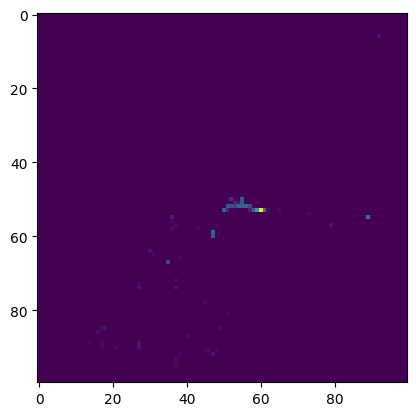

In [ ]:
# Dataset inspection
print("Row",int(meta[0][0]),"corresponds to a neutrino of",meta[0][1], "MeV and produced",int(meta[0][3]),"final state particles")
plt.figure()
plt.imshow(images[0])
plt.show()

## Data Exploration

Before simulating noise, examining the structure of the neutrino images to understand the pixel value scale and image sparsity. This will inform the choice of noise parameters.

Total pixels:        100,000,000
Non-zero pixels:     473,519 (0.47%)
Non-zero mean:       4.66
Non-zero std:        5.83
Non-zero max:        106.00


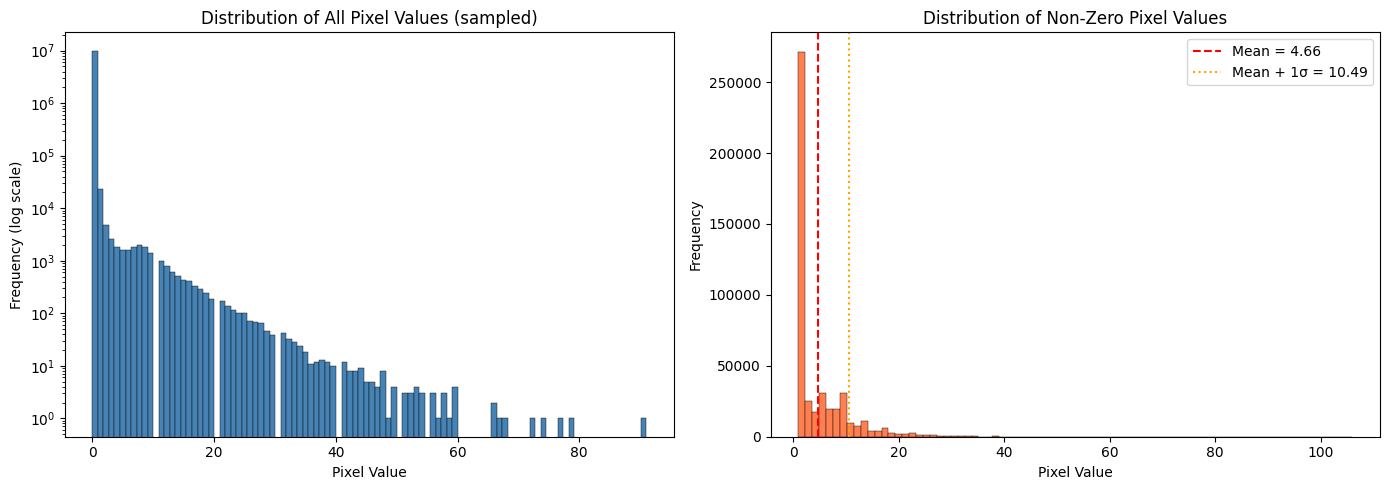

3435

In [9]:
os.makedirs('./figures/', exist_ok=True)

# Pixel value distribution — compute stats without .flatten() to save ~381 MB
total_pixels = images.size
nonzero_mask = images > 0
n_nonzero = nonzero_mask.sum()
nonzero_pixels = images[nonzero_mask]  # 1D array of non-zero values only (much smaller)

print(f"Total pixels:        {total_pixels:,}")
print(f"Non-zero pixels:     {n_nonzero:,} ({100*n_nonzero/total_pixels:.2f}%)")
print(f"Non-zero mean:       {nonzero_pixels.mean():.2f}")
print(f"Non-zero std:        {nonzero_pixels.std():.2f}")
print(f"Non-zero max:        {nonzero_pixels.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sample pixel values for histogram (use subset to avoid huge array)
sample_pixels = images[::10].flatten()  # 1/10 of all pixels — representative enough
axes[0].hist(sample_pixels, bins=100, color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_title('Distribution of All Pixel Values (sampled)')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency (log scale)')
del sample_pixels

# Right: non-zero pixel values only
axes[1].hist(nonzero_pixels, bins=80, color='coral', edgecolor='black', linewidth=0.3)
axes[1].axvline(nonzero_pixels.mean(), color='red', linestyle='--',
                label=f'Mean = {nonzero_pixels.mean():.2f}')
axes[1].axvline(nonzero_pixels.mean() + nonzero_pixels.std(), color='orange',
                linestyle=':', label=f'Mean + 1σ = {nonzero_pixels.mean()+nonzero_pixels.std():.2f}')
axes[1].set_title('Distribution of Non-Zero Pixel Values')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('./figures/pixel_value_distribution.png', dpi=200)
plt.show()

del nonzero_pixels, nonzero_mask
gc.collect()

## Task 1： Electronic Noise Simulation

The detector electronics introduce Gaussian noise $N(0, \sigma^2)$ into every pixel. From the image simulator (`SimpleLarTPCSim`), the baseline noise level is $\sigma = 5$.

**Clipping strategy**: The `generate_noise` function returns **raw** Gaussian noise (both positive and negative values). Clipping at 0 is applied **after** overlaying noise onto signal images, because:
1. Electronic noise physically fluctuates in both directions (raises and lowers pixel readings)
2. Detector energy deposition cannot be negative, so the **combined** image is clipped at 0
3. For pure noise images (background class), we also clip at 0 since they represent detector readouts

In [10]:
# Set up reproducible random number generator
rng = np.random.default_rng(seed=42)

def generate_noise(n, sigma, shape=(100, 100), rng=None):
    """
    Generate n electronic noise images from N(0, sigma^2).

    Returns raw noise (positive and negative values). Clipping should be
    applied downstream after overlaying onto signal images, since electronic
    noise fluctuates in both directions.

    Args:
        n (int): Number of images to generate.
        sigma (float): Standard deviation of Gaussian noise.
        shape (tuple): Image dimensions. Default (100, 100).
        rng (np.random.Generator or None): NumPy random generator for
            reproducibility. If None, uses np.random.default_rng().

    Returns:
        np.ndarray: Array of shape (n, *shape), dtype float32.
    """
    if rng is None:
        rng = np.random.default_rng()
    return rng.normal(0, sigma, size=(n, *shape)).astype(np.float32)


def minmax_norm(data):
    """
    Apply global min-max normalisation to scale pixel values to [0, 1].

    Uses the global min and max across the entire input array. When applied
    to a combined (signal + background) dataset, this preserves the relative
    scale between classes.

    Args:
        data (np.ndarray): Input array of any shape.

    Returns:
        np.ndarray: Normalised array with values in [0, 1].
    """
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val)


# Quick verification
test_noise = generate_noise(5, 5.0, rng=rng)
print(f'Shape: {test_noise.shape}')
print(f'Dtype: {test_noise.dtype}')
print(f'Min:   {test_noise.min():.3f}  (negative values expected — raw noise)')
print(f'Max:   {test_noise.max():.3f}')
print(f'Mean:  {test_noise.mean():.3f}  (should be close to 0)')
print(f'Std:   {test_noise.std():.3f}  (should be close to 5)')

Shape: (5, 100, 100)
Dtype: float32
Min:   -21.946  (negative values expected — raw noise)
Max:   25.036
Mean:  -0.003  (should be close to 0)
Std:   5.013  (should be close to 5)


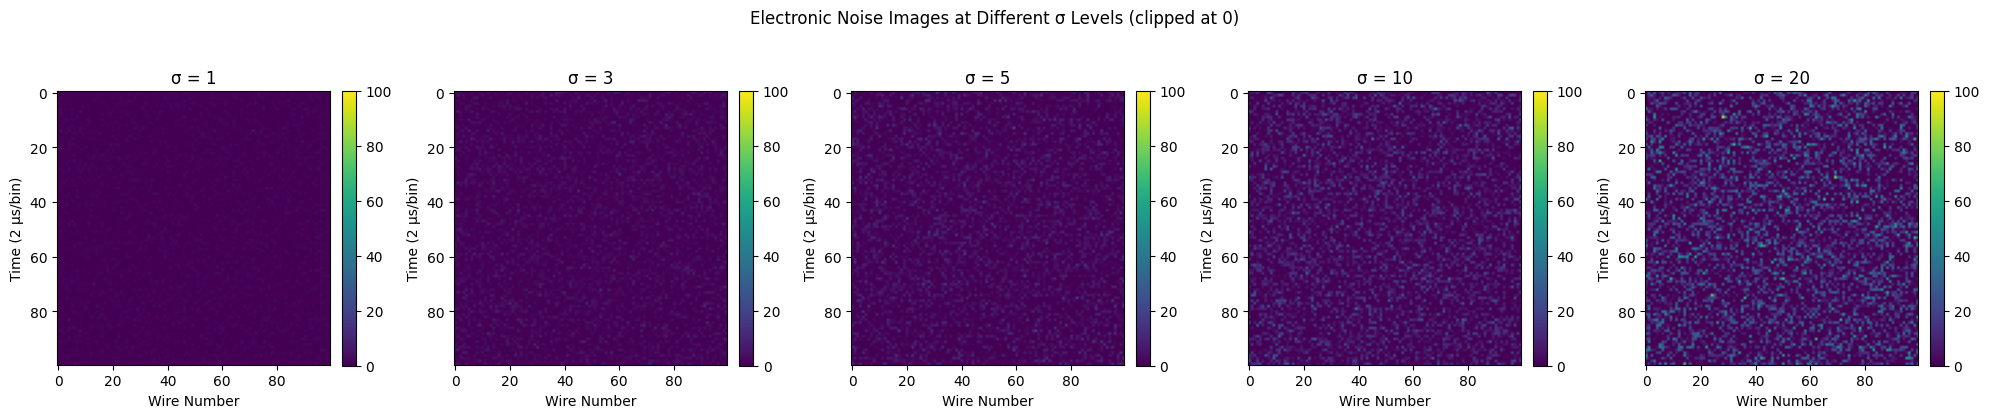

In [11]:
# Visualise noise images at different sigma values
sigma_values = [1, 3, 5, 10, 20]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, sigma in zip(axes, sigma_values):
    noise_img = generate_noise(1, sigma, rng=rng)[0].clip(min=0)
    im = ax.imshow(noise_img, cmap='viridis', vmin=0, vmax=100)
    ax.set_title(f'σ = {sigma}')
    ax.set_xlabel('Wire Number')
    ax.set_ylabel('Time (2 μs/bin)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Electronic Noise Images at Different σ Levels (clipped at 0)', y=1.02)
plt.tight_layout()
plt.savefig('./figures/noise_examples_sigma.png', dpi=200, bbox_inches='tight')
plt.show()

Fraction of zero pixels after clipping: 0.4999 (expected ~0.5)
Mean of clipped noise: 1.9942 (theoretical σ/√(2π) = 1.9947)


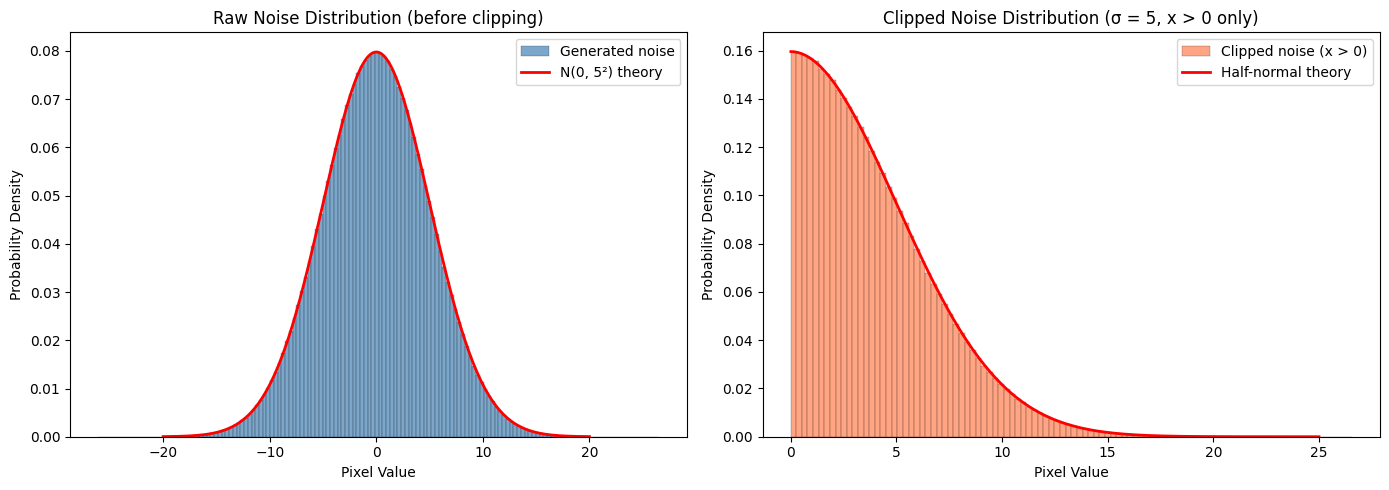

In [12]:
# Noise pixel value distribution at sigma=5
noise_sample = generate_noise(1000, 5.0, rng=rng)
raw_pixels = noise_sample.flatten()
clipped_pixels = raw_pixels.clip(min=0)
nonzero_noise = clipped_pixels[clipped_pixels > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw noise distribution (full Gaussian)
axes[0].hist(raw_pixels, bins=150, density=True, color='steelblue',
             edgecolor='black', linewidth=0.2, alpha=0.7, label='Generated noise')
x = np.linspace(-20, 20, 500)
theoretical_pdf = (1 / (5 * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * 25))
axes[0].plot(x, theoretical_pdf, 'r-', linewidth=2, label='N(0, 5²) theory')
axes[0].set_title('Raw Noise Distribution (before clipping)')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Probability Density')
axes[0].legend()

# Right: non-zero clipped noise distribution
axes[1].hist(nonzero_noise, bins=100, density=True, color='coral',
             edgecolor='black', linewidth=0.2, alpha=0.7, label='Clipped noise (x > 0)')
x_pos = np.linspace(0.01, 25, 500)
# Theoretical: truncated Gaussian (half-normal), renormalised over (0, inf)
half_normal_pdf = 2 * (1 / (5 * np.sqrt(2 * np.pi))) * np.exp(-x_pos**2 / (2 * 25))
axes[1].plot(x_pos, half_normal_pdf, 'r-', linewidth=2, label='Half-normal theory')
axes[1].set_title('Clipped Noise Distribution (σ = 5, x > 0 only)')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Probability Density')
axes[1].legend()

print(f'Fraction of zero pixels after clipping: {(clipped_pixels == 0).mean():.4f} (expected ~0.5)')
print(f'Mean of clipped noise: {clipped_pixels.mean():.4f} (theoretical σ/√(2π) = {5/np.sqrt(2*np.pi):.4f})')

plt.tight_layout()
plt.savefig('./figures/noise_pixel_distribution.png', dpi=200)
plt.show()

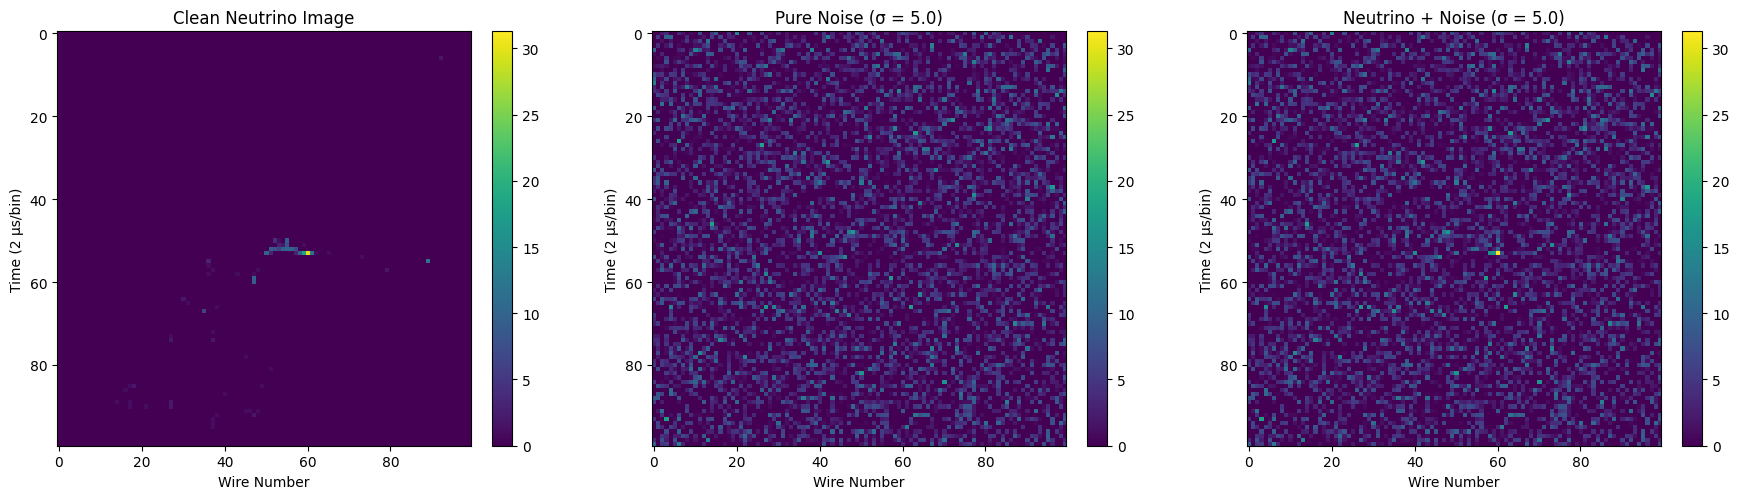

In [ ]:
# The comparison between clean neutrino, pure noise and neutrino+noise
sigma = 5.0
example_idx = 0  # Use the first neutrino image
clean_img = images[example_idx].astype(np.float32)
noise_img = generate_noise(1, sigma, rng=rng)[0]

pure_noise_clipped = noise_img.clip(min=0)
combined = (clean_img + noise_img).clip(min=0)

# Use consistent colour scale across all panels
vmax = max(clean_img.max(), pure_noise_clipped.max(), combined.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Clean Neutrino Image', f'Pure Noise (σ = {sigma})', f'Neutrino + Noise (σ = {sigma})']
data = [clean_img, pure_noise_clipped, combined]

for ax, img, title in zip(axes, data, titles):
    im = ax.imshow(img, cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Wire Number')
    ax.set_ylabel('Time (2 μs/bin)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('./figures/signal_noise_comparison.png', dpi=200)
plt.show()

To ensure physical accuracy, verifing the simulated noise against statistical theory. LArTPC detectors typically discard negative charge fluctuations, which we simulate via **hardware zero-suppression** (`clip(min=0)`).

Applying this to a zero-mean Gaussian $\mathcal{N}(0, \sigma^2)$ creates a **Rectified Gaussian distribution** with two key predictable properties:

1. **Zero Fraction**: Due to symmetry, exactly **$50\%$** of the pixels should become absolute zero (empty background).
2. **Theoretical Mean**: The expected mean of the clipped noise follows the exact mathematical formula:
   $$\mu_{theory} = \frac{\sigma}{\sqrt{2\pi}}$$

The following code validates the integrity of our `generate_noise` function by comparing the empirical statistics (`Clip Mean`, `Zero Frac`) against these theoretical benchmarks.

In [14]:
# Statistical verification of generate_noise across sigma values
sigma_test = [1, 3, 5, 10, 20]
n_test = 1000

print(f'{"σ":>5} | {"Raw Mean":>10} {"Raw Std":>10} | '
      f'{"Clip Mean":>10} {"Theory":>10} {"Clip Std":>10} {"Zero Frac":>10}')
print('-' * 80)

for sigma in sigma_test:
    noise = generate_noise(n_test, sigma, rng=rng)
    raw_mean = noise.mean()
    raw_std = noise.std()

    clipped = noise.clip(min=0)
    clip_mean = clipped.mean()
    clip_std = clipped.std()
    zero_frac = (clipped == 0).mean()

    # Theoretical mean of max(X, 0) where X ~ N(0, sigma^2) is sigma / sqrt(2*pi)
    theory_mean = sigma / np.sqrt(2 * np.pi)

    print(f'{sigma:>5} | {raw_mean:>10.4f} {raw_std:>10.4f} | '
          f'{clip_mean:>10.4f} {theory_mean:>10.4f} {clip_std:>10.4f} {zero_frac:>10.4f}')

print()
print('Expected: Raw Mean ≈ 0, Raw Std ≈ σ, Zero Frac ≈ 0.5, Clip Mean ≈ σ/√(2π)')

    σ |   Raw Mean    Raw Std |  Clip Mean     Theory   Clip Std  Zero Frac
--------------------------------------------------------------------------------
    1 |    -0.0002     0.9999 |     0.3988     0.3989     0.5838     0.5003
    3 |     0.0005     2.9988 |     1.1967     1.1968     1.7512     0.5000
    5 |     0.0006     5.0013 |     1.9952     1.9947     2.9206     0.5001
   10 |     0.0061     9.9994 |     3.9921     3.9894     5.8401     0.4998
   20 |     0.0019    20.0031 |     7.9822     7.9788    11.6796     0.4999

Expected: Raw Mean ≈ 0, Raw Std ≈ σ, Zero Frac ≈ 0.5, Clip Mean ≈ σ/√(2π)


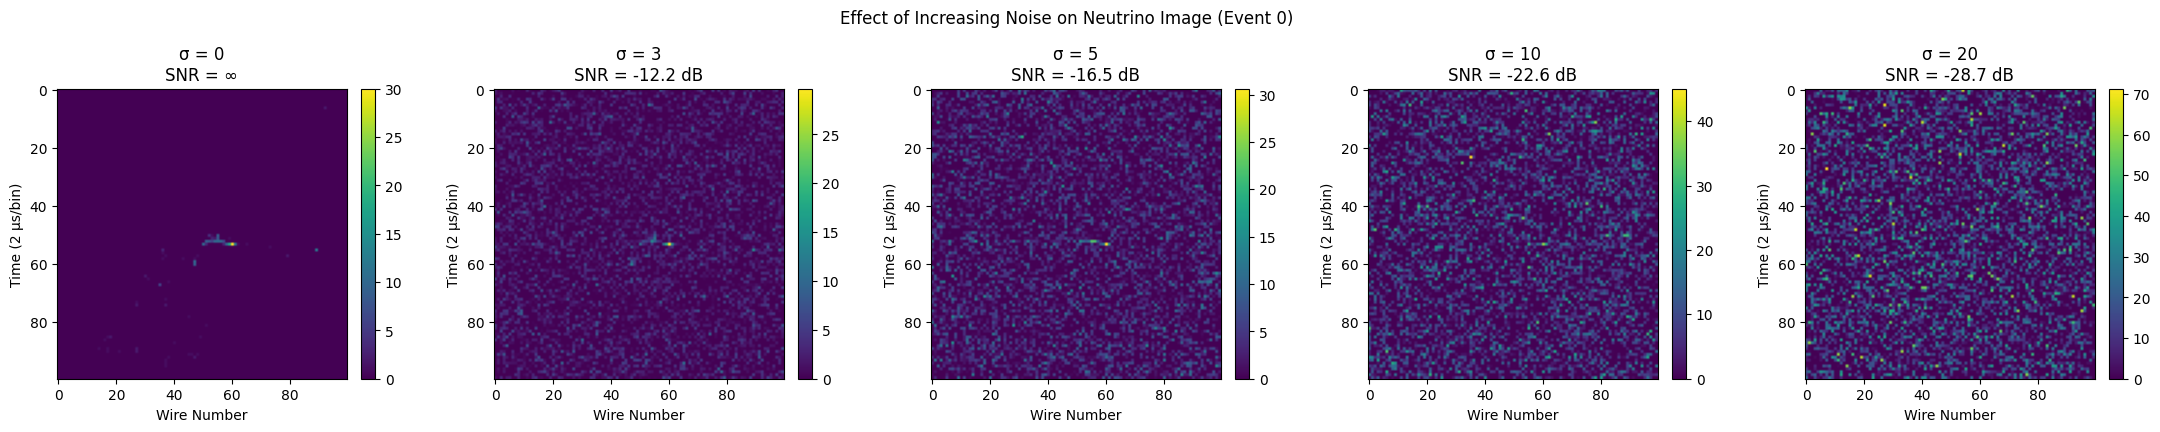


Signal-to-Noise Ratio Summary:
    σ |   SNR (dB)
--------------------
    0 |          ∞
    3 |     -12.17
    5 |     -16.49
   10 |     -22.64
   20 |     -28.70


In [15]:
# Signal degradation: same neutrino image at increasing noise levels
sigma_levels = [0, 3, 5, 10, 20]
example_idx = 0
clean_img = images[example_idx].astype(np.float32)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
snr_values = []

for ax, sigma in zip(axes, sigma_levels):
    if sigma == 0:
        noisy_img = clean_img.copy()
    else:
        noise = generate_noise(1, sigma, rng=rng)[0]
        noisy_img = (clean_img + noise).clip(min=0)

    # Compute SNR: signal power / noise power
    # Signal = clean image pixels, Noise = difference between noisy and clean
    signal_power = np.mean(clean_img ** 2)
    noise_power = np.mean((noisy_img - clean_img) ** 2) if sigma > 0 else np.inf
    snr_db = 10 * np.log10(signal_power / noise_power) if sigma > 0 else np.inf
    snr_values.append((sigma, snr_db))

    im = ax.imshow(noisy_img, cmap='viridis')
    snr_label = f'SNR = {snr_db:.1f} dB' if np.isfinite(snr_db) else 'SNR = ∞'
    ax.set_title(f'σ = {sigma}\n{snr_label}')
    ax.set_xlabel('Wire Number')
    ax.set_ylabel('Time (2 μs/bin)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Effect of Increasing Noise on Neutrino Image (Event {example_idx})', y=1.02)
plt.tight_layout()
plt.savefig('./figures/noise_effect_on_neutrino.png', dpi=200, bbox_inches='tight')
plt.show()

# Print SNR summary
print('\nSignal-to-Noise Ratio Summary:')
print(f'{"σ":>5} | {"SNR (dB)":>10}')
print('-' * 20)
for sigma, snr in snr_values:
    if np.isfinite(snr):
        print(f'{sigma:>5} | {snr:>10.2f}')
    else:
        print(f'{sigma:>5} | {"∞":>10}')

## Task 2 — Classifier (Neutrino+Noise vs Pure Noise)

To train a CNN to distinguish neutrino events (overlaid with electronic noise) from pure noise images.

**Approach:**
1. **Dataset construction**: signal = (neutrino + noise).clip(0), background = noise.clip(0), then min-max normalise the combined set
2. **Train/Val/Test split** on the neutrino image pool (no data leakage)
3. **CNN training** with weight reset between runs
4. **σ sweep**: train at each σ_train, evaluate on all σ_test, report accuracy / efficiency / purity / ROC

4 metrics are used to evaluate classifier performance.

**Accuracy** measures the overall fraction of correctly classified samples:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Efficiency** (true positive rate) measures the fraction of signal events
correctly identified:

$$\text{Efficiency} = \frac{TP}{TP + FN}$$

**Purity** (precision) measures the fraction of signal predictions that are
genuinely signal:

$$\text{Purity} = \frac{TP}{TP + FP}$$

**AUC** (area under the ROC curve) provides a threshold-independent measure
of overall discriminating power, where 1.0 indicates perfect separation and
0.5 indicates random classification.

Efficiency and purity are of particular physical relevance: efficiency
characterises the signal detection rate, while purity quantifies the
contamination of the selected sample by background events. A classification
threshold of 0.5 is applied throughout unless otherwise stated.

In [16]:
def make_dataset(noise_sigma, neutrino_images, rng):
    """
    Build a balanced dataset: neutrino+noise (label=1) vs pure noise (label=0).

    Noise is generated raw and clipped after overlay. The combined dataset is
    globally min-max normalised, reshaped to include a channel dimension, and
    shuffled. Uses in-place operations to minimise peak memory.

    Args:
        noise_sigma (float): Standard deviation of Gaussian noise.
        neutrino_images (np.ndarray): Array of neutrino images, shape (n, 100, 100).
        rng (np.random.Generator): NumPy random generator.

    Returns:
        tuple: (X, y) where X has shape (2n, 100, 100, 1) float32 and
               y is a binary label array of length 2n.
    """
    n = len(neutrino_images)

    # Pre-allocate output array to avoid concatenation copy
    X = np.empty((2 * n, 100, 100), dtype=np.float32)

    # Signal: neutrino + noise, clipped at 0
    noise_s = generate_noise(n, noise_sigma, rng=rng)
    np.add(neutrino_images, noise_s, out=X[:n])
    del noise_s
    np.clip(X[:n], 0, None, out=X[:n])

    # Background: pure noise, clipped at 0
    X[n:] = generate_noise(n, noise_sigma, rng=rng)
    np.clip(X[n:], 0, None, out=X[n:])

    # Normalise in-place
    min_val = X.min()
    max_val = X.max()
    X -= min_val
    X /= (max_val - min_val)

    # Add channel dimension
    X = X[..., np.newaxis]  # (2n, 100, 100, 1), this is a view, no copy

    y = np.concatenate([np.ones(n, dtype=np.float32), np.zeros(n, dtype=np.float32)])

    # Shuffle
    idx = rng.permutation(2 * n)
    return X[idx], y[idx]


def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained binary classifier on a test set.

    Args:
        model: Trained Keras model with sigmoid output.
        X_test (np.ndarray): Test images, shape (N, 100, 100, 1).
        y_test (np.ndarray): True binary labels.

    Returns:
        dict: Contains acc, efficiency (TPR), purity (precision),
              auc, fpr_arr, tpr_arr for ROC plotting.
    """
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = np.round(y_prob).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    efficiency = tp / (tp + fn)                              # TPR / recall
    purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0       # precision
    fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    return dict(acc=acc, efficiency=efficiency, purity=purity,
                auc=auc, fpr_arr=fpr_arr, tpr_arr=tpr_arr,
                tn=tn, fp=fp, fn=fn, tp=tp)


def compute_snr_db(neutrino_images, sigma):
    """
    Compute average Signal-to-Noise Ratio in dB.

    SNR = 10 * log10(signal_power / noise_power), where signal_power is
    the mean squared pixel value of clean neutrino images and noise_power = sigma^2.

    Args:
        neutrino_images (np.ndarray): Clean neutrino images.
        sigma (float): Noise standard deviation.

    Returns:
        float: SNR in dB.
    """
    signal_power = np.mean(neutrino_images.astype(np.float32) ** 2)
    noise_power = sigma ** 2
    return 10 * np.log10(signal_power / noise_power)


print('Functions defined: make_dataset, evaluate_model, compute_snr_db')

Functions defined: make_dataset, evaluate_model, compute_snr_db


X shape: (200, 100, 100, 1)  dtype: float32
y shape: (200,)  unique labels: [0. 1.]
Label balance: 100 signal, 100 background
X value range: [0.0000, 1.0000]


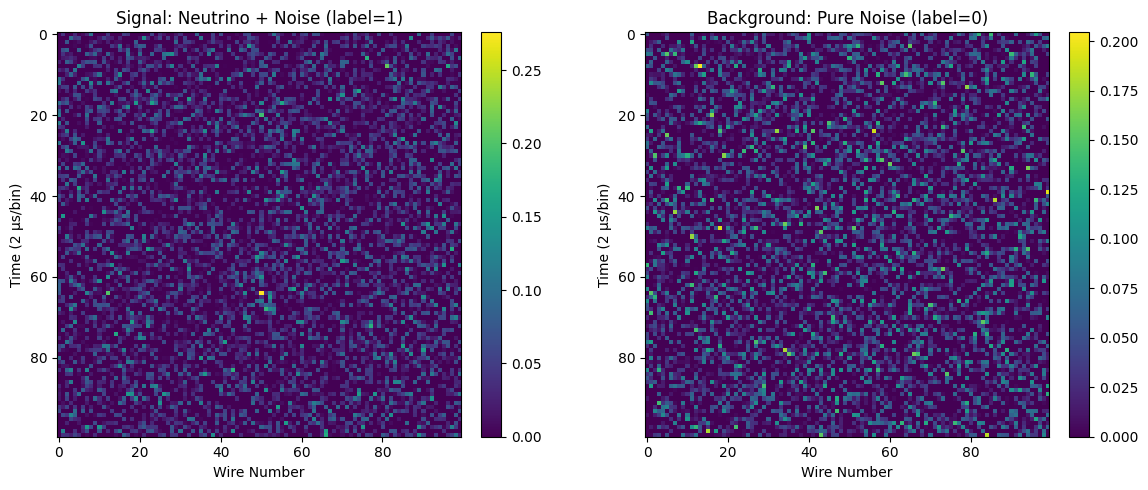

108436

In [17]:
# Demo: build a small dataset at sigma=5 and inspect
demo_imgs = images[:100]  # use 100 neutrino images for quick demo
X_demo, y_demo = make_dataset(5.0, demo_imgs, rng)

print(f'X shape: {X_demo.shape}  dtype: {X_demo.dtype}')
print(f'y shape: {y_demo.shape}  unique labels: {np.unique(y_demo)}')
print(f'Label balance: {(y_demo == 1).sum()} signal, {(y_demo == 0).sum()} background')
print(f'X value range: [{X_demo.min():.4f}, {X_demo.max():.4f}]')

# Show one signal and one background example
idx_sig = np.where(y_demo == 1)[0][0]
idx_bkg = np.where(y_demo == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(X_demo[idx_sig, :, :, 0], cmap='viridis')
axes[0].set_title('Signal: Neutrino + Noise (label=1)')
axes[0].set_xlabel('Wire Number')
axes[0].set_ylabel('Time (2 μs/bin)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(X_demo[idx_bkg, :, :, 0], cmap='viridis')
axes[1].set_title('Background: Pure Noise (label=0)')
axes[1].set_xlabel('Wire Number')
axes[1].set_ylabel('Time (2 μs/bin)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

del X_demo, y_demo, demo_imgs
gc.collect()

In [ ]:
# Split neutrino images into non-overlapping pools
# Use 5000/1500/1500 split to reduce peak memory
split_rng = np.random.default_rng(seed=123)
all_indices = split_rng.permutation(10000)

img_train = images[all_indices[:5000]]    # 5000 neutrinos → 10000 total samples
img_val   = images[all_indices[5000:6500]] # 1500 neutrinos → 3000 total samples
img_test  = images[all_indices[6500:8000]] # 1500 neutrinos → 3000 total samples

# Free original array — splits are independent copies, original no longer needed
del images
gc.collect()

print(f'Neutrino image pools:')
print(f'  Train: {img_train.shape[0]} images → {img_train.shape[0]*2} total samples')
print(f'  Val:   {img_val.shape[0]} images → {img_val.shape[0]*2} total samples')
print(f'  Test:  {img_test.shape[0]} images → {img_test.shape[0]*2} total samples')
print(f'  Memory: {(img_train.nbytes + img_val.nbytes + img_test.nbytes) / 1024**2:.0f} MB')

Neutrino image pools:
  Train: 5000 images → 10000 total samples
  Val:   1500 images → 3000 total samples
  Test:  1500 images → 3000 total samples
  Memory: 305 MB


### CNN Architecture

The architecture consists of three convolutional blocks (filters: 16 → 32 → 32,
kernel size 3×3, ReLU activation), each followed by 2×2 max-pooling. This
progressively reduces spatial resolution while building a hierarchy of features
from low-level edge detections to higher-level track structures. A fully
connected layer (64 units) then aggregates these spatial features into a global
classification decision, followed by a sigmoid output unit returning the
probability of a neutrino event.

Dropout (rate = 0.6) is applied before the output layer to prevent the network
from memorising specific noise realisations, encouraging generalisation across
noise levels. The network is trained using the Adam optimiser
(learning rate = 0.0001) with binary cross-entropy loss, the standard
configuration for binary classification tasks.

In [ ]:
# Create a directory to save model checkpoints
os.makedirs('./checkpoints/', exist_ok=True)

model = keras.models.Sequential()

# First conv block: 16 filters — small capacity intentionally limits overfitting to noise
model.add(keras.layers.Conv2D(16, 3, activation='relu', input_shape=(100, 100, 1)))
# MaxPooling retains the brightest activations, suppressing low-level noise fluctuations
model.add(keras.layers.MaxPooling2D((2, 2)))

# Second conv block: 32 filters to capture more complex spatial features
model.add(keras.layers.Conv2D(32, 3, activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))

# Third conv block: extract higher-level feature combinations
model.add(keras.layers.Conv2D(32, 3, activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))

# Flatten preserves relative spatial positions of activated features
model.add(keras.layers.Flatten())

# Dense layer combines spatial features into a global classification decision
model.add(keras.layers.Dense(64, activation='relu'))
# Dropout 0.6: forces robust feature learning, prevents memorising noise patterns
model.add(keras.layers.Dropout(0.6))

# Sigmoid output: probability of the image containing a neutrino event (label=1)
model.add(keras.layers.Dense(1, activation='sigmoid'))

# Configure the learning process
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Save initial weights for reset between training runs
model.save_weights('./checkpoints/initial_weights.weights.h5')
# Print a table summarizing the network architecture, output shapes, and parameter counts per layer.
model.summary()

/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 98, 98, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 21, 21, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,977 (855.38 KB)

 Trainable params: 218,977 (855.38 KB)

 Non-trainable params: 0 (0.00 B)

### Training Procedure

The network is trained using mini-batches of 64 samples for up to 20 epochs.
Two callbacks are employed: `ReduceLROnPlateau` reduces the learning rate by a
factor of 0.2 if validation loss fails to improve for 2 consecutive epochs
(minimum $10^{-6}$), and `EarlyStopping` halts training and restores the
best weights if validation loss shows no improvement for 6 epochs. Prior to
each training run, the model weights are reset to their initial state and the
optimiser is recompiled, ensuring that results across different σ_train
conditions are fully independent and comparable.

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Baseline training at sigma=5 (physically motivated noise level)
sigma_baseline = 5.0

# Reset weights to initial state
model.load_weights('./checkpoints/initial_weights.weights.h5')

# Reset optimizer state by recompiling
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Build datasets
train_rng = np.random.default_rng(seed=42)
X_train, y_train = make_dataset(sigma_baseline, img_train, train_rng)
X_val, y_val     = make_dataset(sigma_baseline, img_val, train_rng)

print(f'Training set:   {X_train.shape}')
print(f'Validation set: {X_val.shape}')

# The learning rate by 5 if val_loss doesn't improve for 2 epochs, down to a minimum of 1e-6
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=2, 
    verbose=1,
    min_lr=1e-6
)

# Stop training if val_loss doesn't improve for 6 epochs, and restore best weights
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=6, 
    restore_best_weights=True, 
    verbose=1
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Free baseline datasets after training — only history is needed downstream
del X_train, y_train, X_val, y_val
gc.collect()

Training set:   (10000, 100, 100, 1)
Validation set: (3000, 100, 100, 1)
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5469 - loss: 0.6906 - val_accuracy: 0.6150 - val_loss: 0.6824 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7346 - loss: 0.5997 - val_accuracy: 0.8943 - val_loss: 0.3670 - learning_rate: 1.0000e-04
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8999 - loss: 0.2851 - val_accuracy: 0.8850 - val_loss: 0.2862 - learning_rate: 1.0000e-04
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9250 - loss: 0.2076 - val_accuracy: 0.9227 - val_loss: 0.2056 - learning_rate: 1.0000e-04
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9364 - loss: 0.1850 - val_accuracy: 0.9270 - val_loss: 0.1998 - learning_rate: 1.0000e-04
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9413 - loss: 0.1694 - val_accuracy: 0.9310 - val_loss: 0.1924 - learning_rate: 1

13072

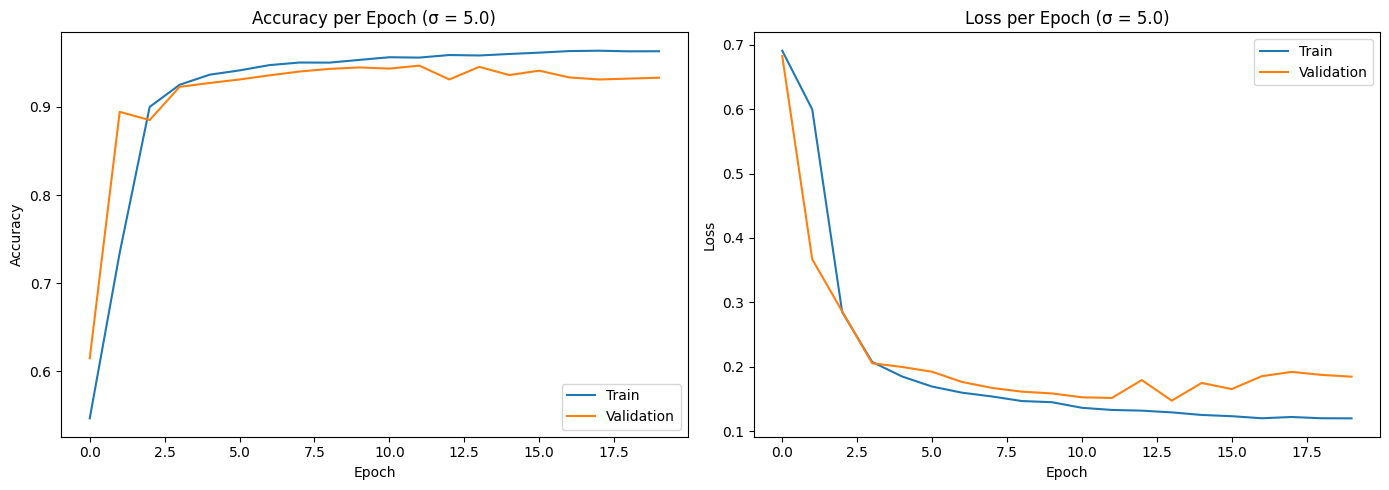


=== Test Results at σ = 5.0 ===
Accuracy:   0.9203
Efficiency: 0.9747  (TPR — signal correctly detected)
Purity:     0.8791  (Precision — signal predictions correct)
AUC:        0.9846

Confusion Matrix:
  TP=1462  FN=38
  FP=201  TN=1299
  FPR=0.1340  FNR=0.0253


In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title(f'Accuracy per Epoch (σ = {sigma_baseline})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title(f'Loss per Epoch (σ = {sigma_baseline})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('./figures/training_curves_sigma5.png', dpi=200)
plt.show()

#  Test set evaluation (rebuild test set — was freed to save memory) 
test_rng = np.random.default_rng(seed=42)
X_test, y_test = make_dataset(sigma_baseline, img_test, test_rng)
res = evaluate_model(model, X_test, y_test)
del X_test, y_test
gc.collect()

print(f'\n=== Test Results at σ = {sigma_baseline} ===')
print(f'Accuracy:   {res["acc"]:.4f}')
print(f'Efficiency: {res["efficiency"]:.4f}  (TPR — signal correctly detected)')
print(f'Purity:     {res["purity"]:.4f}  (Precision — signal predictions correct)')
print(f'AUC:        {res["auc"]:.4f}')
print(f'\nConfusion Matrix:')
print(f'  TP={res["tp"]}  FN={res["fn"]}')
print(f'  FP={res["fp"]}  TN={res["tn"]}')
print(f'  FPR={res["fp"]/(res["fp"]+res["tn"]):.4f}  '
      f'FNR={res["fn"]/(res["fn"]+res["tp"]):.4f}')


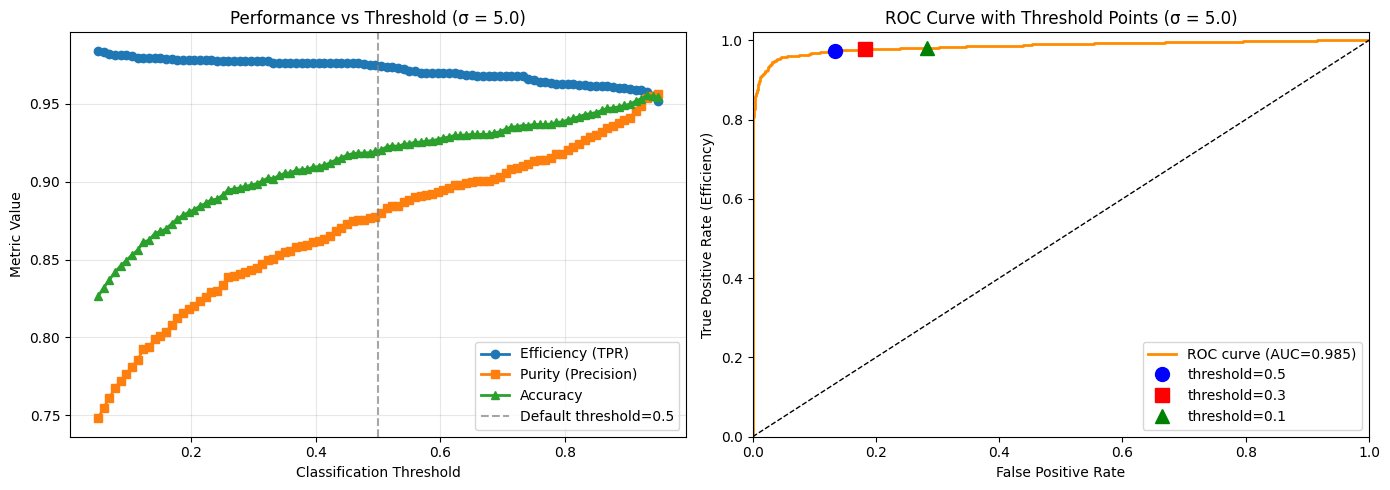


=== Results at threshold = 0.3 ===
Efficiency: 0.9773  (was 0.9747 at 0.5)
Purity:     0.8430  (was 0.8791 at 0.5)
FPR:        0.1820  (was 0.1340 at 0.5)
Accuracy:   0.8977  (was 0.9203 at 0.5)


6950

In [26]:
# === Threshold optimisation ===
# ROC curve already contains TPR/FPR at all thresholds
# Scan thresholds to find the efficiency/purity trade-off

thresholds = np.linspace(0.05, 0.95, 100)

eff_list_thr = []
pur_list_thr = []
fpr_list_thr = []
acc_list_thr = []

# Reuse test set predictions from res (already computed above)
# Need raw probabilities — re-predict on test set
test_rng2 = np.random.default_rng(seed=42)
X_test2, y_test2 = make_dataset(sigma_baseline, img_test, test_rng2)
y_prob = model.predict(X_test2, verbose=0).flatten()

for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test2, y_pred_thr).ravel()
    
    eff_list_thr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    pur_list_thr.append(tp / (tp + fp) if (tp + fp) > 0 else 1)
    fpr_list_thr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    acc_list_thr.append((tp + tn) / (tp + tn + fp + fn))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Efficiency and Purity vs threshold
axes[0].plot(thresholds, eff_list_thr, 'o-', label='Efficiency (TPR)', linewidth=2)
axes[0].plot(thresholds, pur_list_thr, 's-', label='Purity (Precision)', linewidth=2)
axes[0].plot(thresholds, acc_list_thr, '^-', label='Accuracy', linewidth=2)
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold=0.5')
#axes[0].axvline(0.3, color='red',  linestyle='--', alpha=0.7, label='Suggested threshold=0.3')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Metric Value')
axes[0].set_title(f'Performance vs Threshold (σ = {sigma_baseline})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: ROC curve with threshold points marked
axes[1].plot(res['fpr_arr'], res['tpr_arr'], color='darkorange', lw=2,
             label=f'ROC curve (AUC={res["auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)

# Mark specific threshold points
for thr, color, marker in [(0.5, 'blue', 'o'), (0.3, 'red', 's'), (0.1, 'green', '^')]:
    idx = np.argmin(np.abs(thresholds - thr))
    axes[1].plot(fpr_list_thr[idx], eff_list_thr[idx], marker, color=color,
                 markersize=10, label=f'threshold={thr}', zorder=5)

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Efficiency)')
axes[1].set_title(f'ROC Curve with Threshold Points (σ = {sigma_baseline})')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('./figures/threshold_optimisation.png', dpi=200)
plt.show()

# Print results at threshold=0.3
idx_03 = np.argmin(np.abs(thresholds - 0.3))
print(f'\n=== Results at threshold = 0.3 ===')
print(f'Efficiency: {eff_list_thr[idx_03]:.4f}  (was {res["efficiency"]:.4f} at 0.5)')
print(f'Purity:     {pur_list_thr[idx_03]:.4f}  (was {res["purity"]:.4f} at 0.5)')
print(f'FPR:        {fpr_list_thr[idx_03]:.4f}  (was {res["fp"]/(res["fp"]+res["tn"]):.4f} at 0.5)')
print(f'Accuracy:   {acc_list_thr[idx_03]:.4f}  (was {res["acc"]:.4f} at 0.5)')

del X_test2, y_test2, y_prob
gc.collect()

## Task 3

In this task, the CNN was trained at different noise levels (σ_train) and evaluate each trained model across all noise levels (σ_test). This produces a 2D performance matrix that reveals:
1. How well the classifier generalises across noise conditions
2. At which noise level (σ) performance begins to degrade
3. Whether training at a specific σ offers robustness advantages

In [27]:
# σ sweep: train at each sigma_train, evaluate on all sigma_test
sigma_train_list = [1, 3, 5, 6, 7, 9, 10, 15]
sigma_test_list  = [1, 3, 5, 6, 7, 9, 10, 15]

results = {}  # results[(sigma_train, sigma_test)] = evaluation dict

for sigma_train in sigma_train_list:
    print(f'\n--- Training at σ_train = {sigma_train} ---')

    # Reset weights before each training run
    model.load_weights('./checkpoints/initial_weights.weights.h5')

    # Reset optimizer state by recompiling
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
    )

    # Build training and validation sets at this noise level
    sweep_rng = np.random.default_rng(seed=42)
    X_tr, y_tr = make_dataset(sigma_train, img_train, sweep_rng)
    X_va, y_va = make_dataset(sigma_train, img_val, sweep_rng)

    # Redefine callbacks to reset their state for each training run
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)

    # Train
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=30, batch_size=64, callbacks=[es, lr], verbose=0)

    # Save trained model for this sigma_train
    model.save(f'./checkpoints/model_sigma{sigma_train}.keras')

    # Free training data before evaluation loop
    del X_tr, y_tr, X_va, y_va
    gc.collect()

    # Evaluate on all test noise levels
    for sigma_test in sigma_test_list:
        eval_rng = np.random.default_rng(seed=99)
        X_te, y_te = make_dataset(sigma_test, img_test, eval_rng)
        res = evaluate_model(model, X_te, y_te)
        results[(sigma_train, sigma_test)] = res
        print(f'  σ_test={sigma_test:>2}  acc={res["acc"]:.3f}  '
              f'eff={res["efficiency"]:.3f}  pur={res["purity"]:.3f}  '
              f'AUC={res["auc"]:.3f}')
        del X_te, y_te

    gc.collect()

print('\nSweep complete. Models saved to ./checkpoints/')


--- Training at σ_train = 1 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  σ_test= 1  acc=0.999  eff=0.999  pur=1.000  AUC=1.000
  σ_test= 3  acc=0.946  eff=0.992  pur=0.909  AUC=0.997
  σ_test= 5  acc=0.867  eff=0.939  pur=0.821  AUC=0.956
  σ_test= 6  acc=0.827  eff=0.891  pur=0.790  AUC=0.914
  σ_test= 7  acc=0.789  eff=0.835  pur=0.764  AUC=0.866
  σ_test= 9  acc=0.716  eff=0.737  pur=0.708  AUC=0.782
  σ_test=10  acc=0.694  eff=0.703  pur=0.690  AUC=0.748
  σ_test=15  acc=0.614  eff=0.582  pur=0.622  AUC=0.651

--- Training at σ_train = 3 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  σ_test= 1  acc=1.000  eff=0.999  pur=1.000  AUC=1.000
  σ_test= 3  acc=0.993  eff=0.989  pur=0.997  AUC=0.999
  σ_test= 5  acc=0.748  eff=0.497  pur=1.000  AUC=0.973
  σ_test= 6  acc=0.610  eff=0.219  pur=1.000  AUC=0.937
  σ_test= 7  acc=0.546  eff=0.093  pur=1.000  AUC=0.894
  σ_test= 9  acc=0.509  eff=0.017  pur=1.000  AUC=0.794
  σ_test=10  acc=0.504  eff=0.007  pur=1.000  AUC=0.684
  σ_test=15  acc=0.500  eff=0.000  pur=0.000  AUC=0.510

--- Training at σ_train = 5 ---


...

  σ_test= 1  acc=0.761  eff=0.523  pur=1.000  AUC=0.953
  σ_test= 3  acc=0.806  eff=0.611  pur=1.000  AUC=0.974
  σ_test= 5  acc=0.888  eff=0.777  pur=0.999  AUC=0.981
  σ_test= 6  acc=0.902  eff=0.825  pur=0.976  AUC=0.966
  σ_test= 7  acc=0.862  eff=0.875  pur=0.852  AUC=0.935
  σ_test= 9  acc=0.591  eff=0.981  pur=0.551  AUC=0.856
  σ_test=10  acc=0.527  eff=0.994  pur=0.514  AUC=0.821
  σ_test=15  acc=0.500  eff=1.000  pur=0.500  AUC=0.697

--- Training at σ_train = 10 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  σ_test= 1  acc=0.729  eff=0.458  pur=1.000  AUC=0.934
  σ_test= 3  acc=0.776  eff=0.553  pur=1.000  AUC=0.961
  σ_test= 5  acc=0.846  eff=0.691  pur=1.000  AUC=0.974
  σ_test= 6  acc=0.871  eff=0.749  pur=0.990  AUC=0.962
  σ_test= 7  acc=0.863  eff=0.800  pur=0.916  AUC=0.935
  σ_test= 9  acc=0.626  eff=0.969  pur=0.575  AUC=0.860
  σ_test=10  acc=0.529  eff=0.993  pur=0.515  AUC=0.825
  σ_test=15  acc=0.500  eff=1.000  pur=0.500  AUC=0.706

--- Training at σ_train = 15 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  σ_test= 1  acc=0.619  eff=0.239  pur=1.000  AUC=0.837
  σ_test= 3  acc=0.630  eff=0.261  pur=1.000  AUC=0.890
  σ_test= 5  acc=0.669  eff=0.339  pur=1.000  AUC=0.919
  σ_test= 6  acc=0.701  eff=0.403  pur=1.000  AUC=0.921
  σ_test= 7  acc=0.760  eff=0.528  pur=0.984  AUC=0.911
  σ_test= 9  acc=0.780  eff=0.752  pur=0.796  AUC=0.850
  σ_test=10  acc=0.733  eff=0.771  pur=0.717  AUC=0.815
  σ_test=15  acc=0.638  eff=0.733  pur=0.616  AUC=0.701

Sweep complete. Models saved to ./checkpoints/


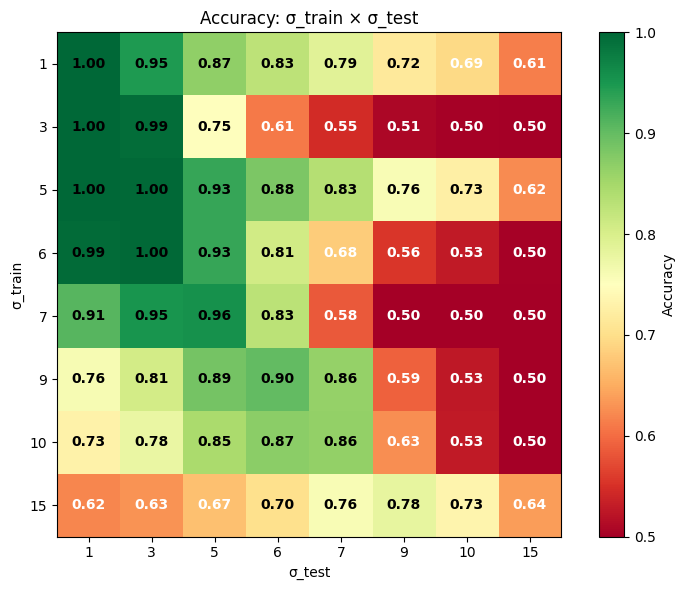

In [28]:
# Build accuracy matrix for heatmap
acc_matrix = np.zeros((len(sigma_train_list), len(sigma_test_list)))
for i, st in enumerate(sigma_train_list):
    for j, se in enumerate(sigma_test_list):
        acc_matrix[i, j] = results[(st, se)]['acc']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(acc_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0)

# Annotate each cell with accuracy value
for i in range(len(sigma_train_list)):
    for j in range(len(sigma_test_list)):
        val = acc_matrix[i, j]
        color = 'white' if val < 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=color, fontsize=10, fontweight='bold')

ax.set_xticks(range(len(sigma_test_list)))
ax.set_xticklabels(sigma_test_list)
ax.set_yticks(range(len(sigma_train_list)))
ax.set_yticklabels(sigma_train_list)
ax.set_xlabel('σ_test')
ax.set_ylabel('σ_train')
ax.set_title('Accuracy: σ_train × σ_test')
plt.colorbar(im, ax=ax, label='Accuracy')

plt.tight_layout()
plt.savefig('./figures/sigma_sweep_heatmap.png', dpi=200)
plt.show()

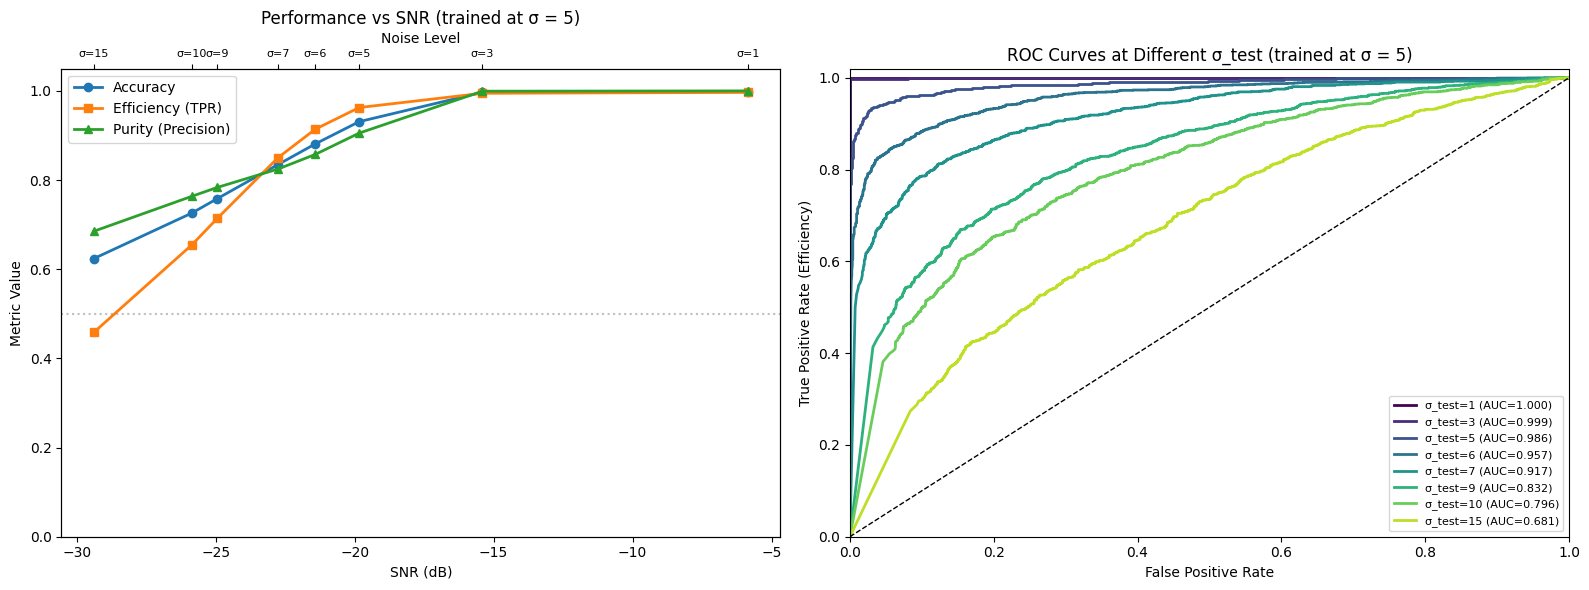


SNR Reference:
    σ |   SNR (dB)
--------------------
    1 |      -5.86
    3 |     -15.40
    5 |     -19.84
    6 |     -21.42
    7 |     -22.76
    9 |     -24.94
   10 |     -25.86
   15 |     -29.38


31425

In [29]:
# Compute SNR for each sigma_test (using test neutrino images)
snr_values = {sigma: compute_snr_db(img_test, sigma) for sigma in sigma_test_list}

# === Performance vs SNR (for model trained at sigma=5) ===
sigma_train_fixed = 5
snr_list = [snr_values[s] for s in sigma_test_list]
acc_list = [results[(sigma_train_fixed, s)]['acc'] for s in sigma_test_list]
eff_list = [results[(sigma_train_fixed, s)]['efficiency'] for s in sigma_test_list]
pur_list = [results[(sigma_train_fixed, s)]['purity'] for s in sigma_test_list]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: performance metrics vs SNR
axes[0].plot(snr_list, acc_list, 'o-', label='Accuracy', linewidth=2)
axes[0].plot(snr_list, eff_list, 's-', label='Efficiency (TPR)', linewidth=2)
axes[0].plot(snr_list, pur_list, '^-', label='Purity (Precision)', linewidth=2)
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('Metric Value')
axes[0].set_title(f'Performance vs SNR (trained at σ = {sigma_train_fixed})')
axes[0].legend()
axes[0].set_ylim([0, 1.05])
axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')

# Add sigma labels on top x-axis
ax2 = axes[0].twiny()
ax2.set_xlim(axes[0].get_xlim())
ax2.set_xticks(snr_list)
ax2.set_xticklabels([f'σ={s}' for s in sigma_test_list], fontsize=8)
ax2.set_xlabel('Noise Level')

# Right: ROC curves at different sigma_test
colors = plt.cm.viridis(np.linspace(0, 0.9, len(sigma_test_list)))
for sigma_test, color in zip(sigma_test_list, colors):
    r = results[(sigma_train_fixed, sigma_test)]
    axes[1].plot(r['fpr_arr'], r['tpr_arr'], color=color, lw=2,
                label=f'σ_test={sigma_test} (AUC={r["auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Efficiency)')
axes[1].set_title(f'ROC Curves at Different σ_test (trained at σ = {sigma_train_fixed})')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('./figures/performance_vs_snr.png', dpi=200)
plt.show()

# Print SNR reference table
print('\nSNR Reference:')
print(f'{"σ":>5} | {"SNR (dB)":>10}')
print('-' * 20)
for sigma in sigma_test_list:
    print(f'{sigma:>5} | {snr_values[sigma]:>10.2f}')

gc.collect()

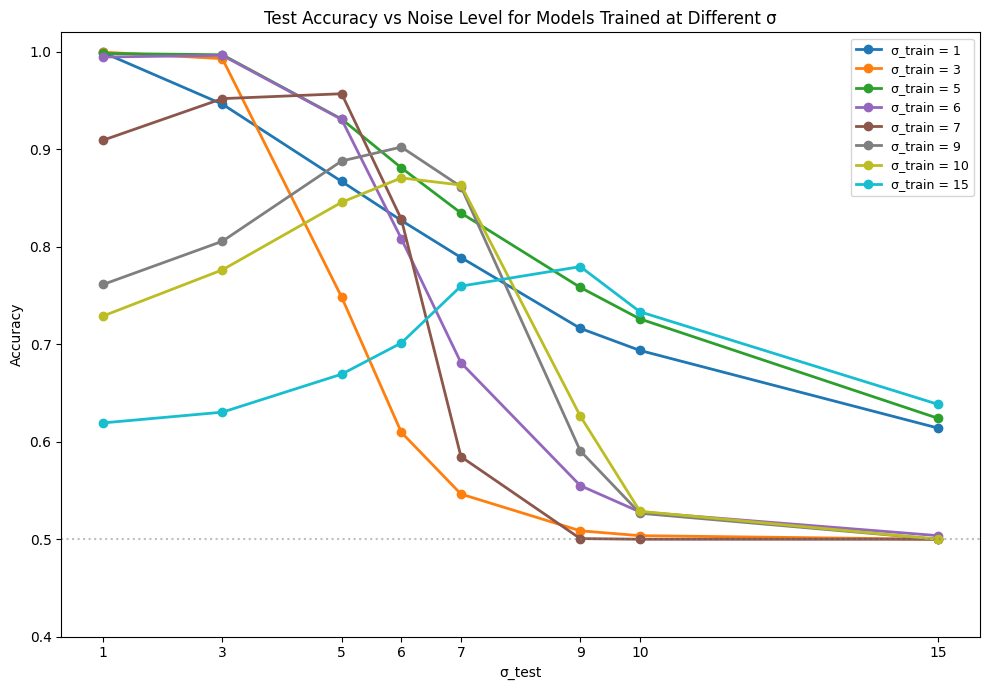

In [30]:
# Performance curves: accuracy vs σ_test for each σ_train model
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(sigma_train_list)))
for sigma_train, color in zip(sigma_train_list, colors):
    acc_vals = [results[(sigma_train, st)]['acc'] for st in sigma_test_list]
    ax.plot(sigma_test_list, acc_vals, 'o-', color=color, linewidth=2,
            markersize=6, label=f'σ_train = {sigma_train}')

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('σ_test')
ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy vs Noise Level for Models Trained at Different σ')
ax.legend(loc='best', fontsize=9)
ax.set_ylim([0.4, 1.02])
ax.set_xticks(sigma_test_list)

plt.tight_layout()
plt.savefig('./figures/accuracy_vs_sigma_test_all_models.png', dpi=200)
plt.show()

In [31]:
# Identify best models: (1) best average accuracy, (2) best single-point accuracy

# Best average: highest mean accuracy across all sigma_test
avg_acc = {}
for sigma_train in sigma_train_list:
    accs = [results[(sigma_train, st)]['acc'] for st in sigma_test_list]
    avg_acc[sigma_train] = np.mean(accs)

best_avg_sigma = max(avg_acc, key=avg_acc.get)

# Best peak: highest single accuracy across all (sigma_train, sigma_test) pairs
best_peak_sigma, best_peak_test = max(
    ((st, se) for st in sigma_train_list for se in sigma_test_list),
    key=lambda pair: results[pair]['acc']
)

print('=== Best Model Selection ===')
print(f'\nBest average accuracy:  σ_train = {best_avg_sigma}  '
      f'(mean acc = {avg_acc[best_avg_sigma]:.4f})')
print(f'Best peak accuracy:     σ_train = {best_peak_sigma}  '
      f'(acc = {results[(best_peak_sigma, best_peak_test)]["acc"]:.4f} '
      f'at σ_test = {best_peak_test})')

# Print full average accuracy ranking
print(f'\nAverage accuracy ranking:')
for sigma, acc in sorted(avg_acc.items(), key=lambda x: -x[1]):
    marker = ' ← best' if sigma == best_avg_sigma else ''
    print(f'  σ_train = {sigma:>2}:  mean acc = {acc:.4f}{marker}')

# Save best model(s)
import shutil

if best_avg_sigma == best_peak_sigma:
    print(f'\nBoth criteria select the same model (σ_train = {best_avg_sigma}).')
    shutil.copy(
        f'./checkpoints/model_sigma{best_avg_sigma}.keras',
        './checkpoints/best_model.keras'
    )
    print(f'Saved: ./checkpoints/best_model.keras')
else:
    print(f'\nDifferent models selected — saving both.')
    shutil.copy(
        f'./checkpoints/model_sigma{best_avg_sigma}.keras',
        './checkpoints/best_model_avg.keras'
    )
    shutil.copy(
        f'./checkpoints/model_sigma{best_peak_sigma}.keras',
        './checkpoints/best_model_peak.keras'
    )
    print(f'Saved: ./checkpoints/best_model_avg.keras  (σ_train = {best_avg_sigma})')
    print(f'Saved: ./checkpoints/best_model_peak.keras (σ_train = {best_peak_sigma})')

=== Best Model Selection ===

Best average accuracy:  σ_train = 5  (mean acc = 0.8438)
Best peak accuracy:     σ_train = 3  (acc = 0.9997 at σ_test = 1)

Average accuracy ranking:
  σ_train =  5:  mean acc = 0.8438 ← best
  σ_train =  1:  mean acc = 0.8066
  σ_train =  6:  mean acc = 0.7497
  σ_train =  9:  mean acc = 0.7295
  σ_train = 10:  mean acc = 0.7175
  σ_train =  7:  mean acc = 0.7165
  σ_train = 15:  mean acc = 0.6914
  σ_train =  3:  mean acc = 0.6762

Different models selected — saving both.
Saved: ./checkpoints/best_model_avg.keras  (σ_train = 5)
Saved: ./checkpoints/best_model_peak.keras (σ_train = 3)


### Discussion

The baseline classifier, trained at the physically motivated noise level
σ = 5, achieves the strongest generalisation across all test conditions,
with a mean test accuracy of 0.84 and near-perfect performance ($\ge$ 0.93)
at σ_test $\le$ 5. This indicates that training at the true operating noise
level yields the most robust classifier, consistent with the model learning
features representative of the actual signal-to-noise regime.

The accuracy heatmap reveals a clear failure boundary near σ_test = 7,
beyond which most models drop below 0.70 accuracy. Models trained at
higher noise levels (σ_train $\ge$ 7) show degraded performance even on
low-noise test conditions, suggesting that excessive noise during training
suppresses the subtle track features required for generalisation.
Across all σ_train configurations, accuracy decreases monotonically with
increasing σ_test, confirming that rising noise levels systematically
decrease classifier performance irrespective of training strategy.

## Extension 1: Radioactive Noise Simulation

Unlike electronic noise, which adds independent Gaussian fluctuations to
every pixel, radioactive decays deposit energy in small, spatially
concentrated regions that appear as 2D Gaussian blobs in the detector images.
Each blob is modelled as a 2D Gaussian of the form

$$f(x, y) = A \exp\!\left(-\frac{(x - x_0)^2}{2\sigma_x^2} - \frac{(y - y_0)^2}{2\sigma_y^2}\right)$$

where $A$ is the peak amplitude, $(x_0, y_0)$ the blob centre, and
$\sigma_x$, $\sigma_y$ the spatial spread. The number of blobs per image
follows a Poisson distribution with mean $\lambda$.

In this section:
1. A generator for radioactive noise images is defined with tuneable $\lambda$.
2. The noise is visualised and its pixel distribution compared with electronic noise.
3. A CNN classifier (neutrino + radioactive noise vs pure radioactive noise) is trained across a sweep of $\lambda$ values.
4. Classification performance is compared against the electronic noise results from Task 3.

In [ ]:
def generate_radioactive_noise(n, lam, amp_range=(5.0, 30.0),
                               sigma_range=(1.0, 3.0), shape=(100, 100), rng=None):
    """
    Generate n images of radioactive noise as randomly placed 2D Gaussian blobs.

    Simulates radioisotope contamination in a LArTPC detector.
    Each image contains Poisson(lambda) blobs at random positions, with random
    amplitude and spatial spread drawn uniformly from the specified ranges.

    Args:
        n (int): Number of images to generate.
        lam (float): Mean number of blobs per image (Poisson parameter).
        amp_range (tuple): (min, max) peak amplitude A for each blob.
        sigma_range (tuple): (min, max) spatial spread sigma for each blob.
        shape (tuple): Image dimensions, default (100, 100).
        rng (np.random.Generator or None): NumPy random generator for
            reproducibility. If None, uses np.random.default_rng().

    Returns:
        np.ndarray: Array of shape (n, *shape), dtype float32.
    """
    if rng is None:
        rng = np.random.default_rng()
    images_out = np.zeros((n, *shape), dtype=np.float32)
    yy, xx = np.meshgrid(np.arange(shape[0], dtype=np.float32),
                         np.arange(shape[1], dtype=np.float32), indexing='ij')

    for i in range(n):
        num_blobs = rng.poisson(lam)
        for _ in range(num_blobs):
            x0 = rng.uniform(0, shape[1])
            y0 = rng.uniform(0, shape[0])
            A  = rng.uniform(*amp_range)
            sx = rng.uniform(*sigma_range)
            sy = rng.uniform(*sigma_range)
            blob = A * np.exp(-((xx - x0)**2 / (2 * sx**2) + (yy - y0)**2 / (2 * sy**2)))
            images_out[i] += blob

    return images_out


# Quick verification
test_rng = np.random.default_rng(seed=42)
radio_test = generate_radioactive_noise(3, lam=5, rng=test_rng)
print(f'Shape: {radio_test.shape}, dtype: {radio_test.dtype}')
print(f'Min: {radio_test.min():.3f}, Max: {radio_test.max():.3f}, Mean: {radio_test.mean():.3f}')
print(f'Non-zero fraction: {(radio_test > 0.01).mean():.4f}')
del radio_test

Shape: (3, 100, 100), dtype: float32
Min: 0.000, Max: 30.870, Mean: 0.230
Non-zero fraction: 0.0841


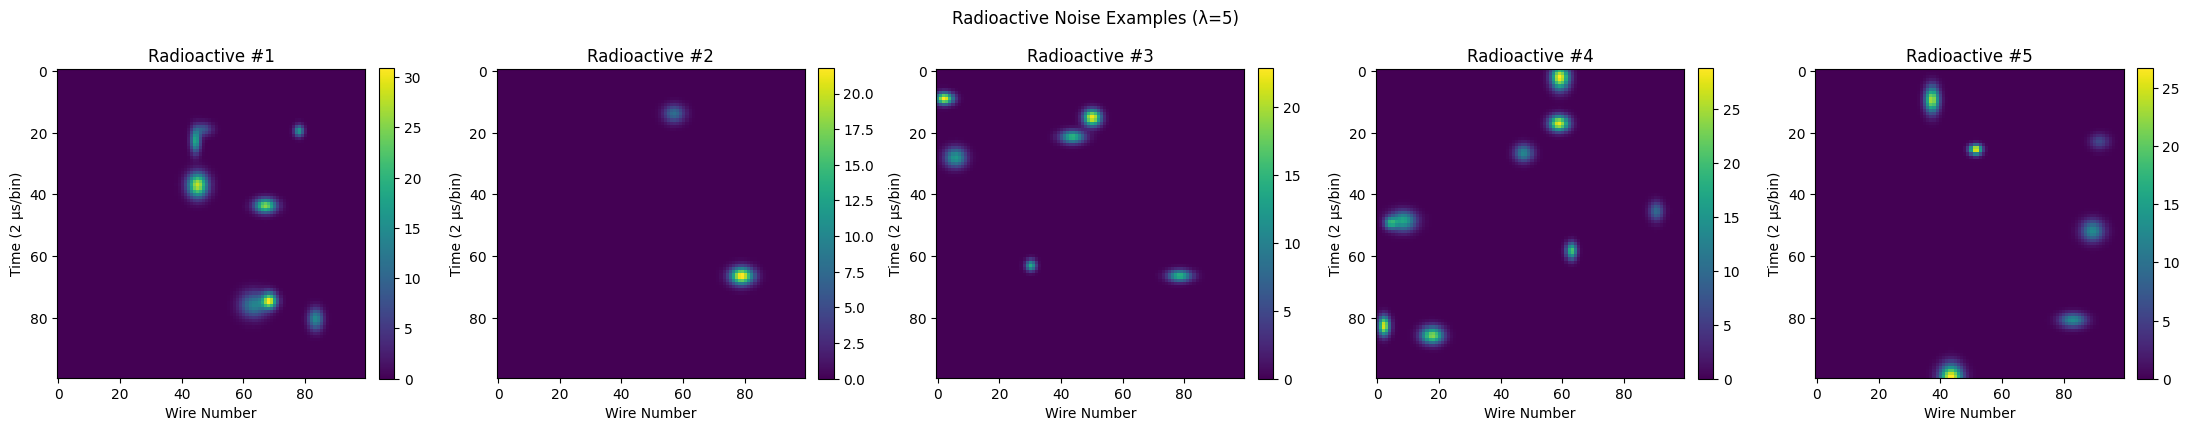

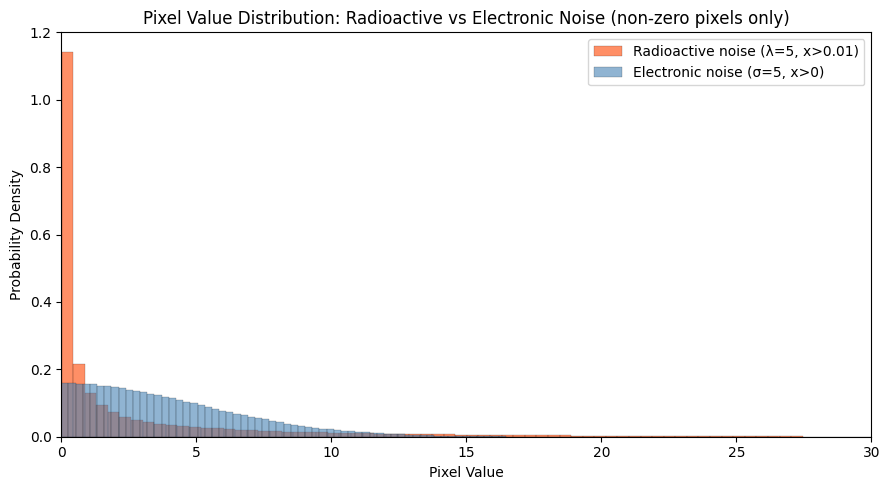

In [34]:
# Visualise 5 example radioactive noise images
viz_rng = np.random.default_rng(seed=42)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for j in range(5):
    img = generate_radioactive_noise(1, lam=5, rng=viz_rng)[0]
    im = axes[j].imshow(img, cmap='viridis')
    axes[j].set_title(f'Radioactive #{j+1}')
    axes[j].set_xlabel('Wire Number')
    axes[j].set_ylabel('Time (2 \u03bcs/bin)')
    plt.colorbar(im, ax=axes[j], fraction=0.046, pad=0.04)

plt.suptitle('Radioactive Noise Examples (\u03bb=5)', y=1.02)
plt.tight_layout()
plt.savefig('./figures/radioactive_noise_examples.png', dpi=200, bbox_inches='tight')
plt.show()

# Pixel distribution comparison: radioactive noise vs electronic noise (\u03c3=5)
radio_sample = generate_radioactive_noise(500, lam=5, rng=np.random.default_rng(42))
elec_sample = generate_noise(500, 5.0, rng=np.random.default_rng(42)).clip(min=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(radio_sample[radio_sample > 0.01].flatten(), bins=100, density=True, alpha=0.6,
        color='orangered', label='Radioactive noise (\u03bb=5, x>0.01)', edgecolor='black', linewidth=0.2)
ax.hist(elec_sample[elec_sample > 0].flatten(), bins=100, density=True, alpha=0.6,
        color='steelblue', label='Electronic noise (\u03c3=5, x>0)', edgecolor='black', linewidth=0.2)
ax.set_title('Pixel Value Distribution: Radioactive vs Electronic Noise (non-zero pixels only)')
ax.set_xlabel('Pixel Value')
ax.set_ylabel('Probability Density')
ax.legend()
ax.set_xlim([0, 30])
plt.tight_layout()
plt.savefig('./figures/radioactive_pixel_distribution.png', dpi=200)
plt.show()

del radio_sample, elec_sample

In [35]:
def make_dataset_radio(neutrino_images, lam, amp_range=(5.0, 30.0),
                       sigma_range=(1.0, 3.0), rng=None):
    """
    Build a balanced dataset: neutrino+radioactive_noise (label=1)
    vs pure radioactive_noise (label=0).

    Same structure as make_dataset() but uses randomly placed 2D Gaussian
    blob noise instead of electronic Gaussian noise. Pre-allocates arrays
    and normalises in-place to minimise peak memory usage.

    Args:
        neutrino_images (np.ndarray): Array of neutrino images, shape (n, 100, 100).
        lam (float): Mean number of blobs per image (Poisson parameter).
        amp_range (tuple): (min, max) blob peak amplitude.
        sigma_range (tuple): (min, max) blob spatial spread.
        rng (np.random.Generator or None): NumPy random generator.

    Returns:
        tuple: (X, y) where X has shape (2n, 100, 100, 1) float32 and
               y is a binary label array of length 2n.
    """
    if rng is None:
        rng = np.random.default_rng()
    n = len(neutrino_images)

    # Pre-allocate output array to avoid concatenation copy
    X = np.empty((2 * n, 100, 100), dtype=np.float32)

    # Signal: neutrino + radioactive noise, clipped at 0
    noise_s = generate_radioactive_noise(n, lam, amp_range, sigma_range, rng=rng)
    np.add(neutrino_images, noise_s, out=X[:n])
    del noise_s
    np.clip(X[:n], 0, None, out=X[:n])

    # Background: pure radioactive noise, clipped at 0
    X[n:] = generate_radioactive_noise(n, lam, amp_range, sigma_range, rng=rng)
    np.clip(X[n:], 0, None, out=X[n:])

    # Normalise in-place
    min_val = X.min()
    max_val = X.max()
    X -= min_val
    X /= (max_val - min_val)

    # Add channel dimension
    X = X[..., np.newaxis]  # (2n, 100, 100, 1), this is a view, no copy

    y = np.concatenate([np.ones(n, dtype=np.float32), np.zeros(n, dtype=np.float32)])

    # Shuffle
    idx = rng.permutation(2 * n)
    return X[idx], y[idx]

In [36]:
# Build CNN for radioactive noise classification — identical architecture
model_radio = keras.models.Sequential()

# First conv block: 16 filters — small capacity intentionally limits overfitting to noise
model_radio.add(keras.layers.Conv2D(16, 3, activation='relu', input_shape=(100, 100, 1)))
# MaxPooling retains the brightest activations, suppressing low-level noise fluctuations
model_radio.add(keras.layers.MaxPooling2D((2, 2)))

# Second conv block: 32 filters to capture more complex spatial features
model_radio.add(keras.layers.Conv2D(32, 3, activation='relu'))
model_radio.add(keras.layers.MaxPooling2D((2, 2)))

# Third conv block: extract higher-level feature combinations
model_radio.add(keras.layers.Conv2D(32, 3, activation='relu'))
model_radio.add(keras.layers.MaxPooling2D((2, 2)))

# Flatten preserves relative spatial positions of activated features
model_radio.add(keras.layers.Flatten())

# Dense layer combines spatial features into a global classification decision
model_radio.add(keras.layers.Dense(64, activation='relu'))
# Dropout 0.6: forces robust feature learning, prevents memorising noise patterns
model_radio.add(keras.layers.Dropout(0.6))

# Sigmoid output: probability of the image containing a neutrino event (label=1)
model_radio.add(keras.layers.Dense(1, activation='sigmoid'))

model_radio.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Save initial weights for reset between training runs
model_radio.save_weights('./checkpoints/radio_initial_weights.weights.h5')
print('Saved initial weights: ./checkpoints/radio_initial_weights.weights.h5')
model_radio.summary()

Saved initial weights: ./checkpoints/radio_initial_weights.weights.h5


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 98, 98, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 21, 21, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,977 (855.38 KB)

 Trainable params: 218,977 (855.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Lambda sweep: train at each lam, evaluate on test set
lam_list = [1, 5, 10, 50, 100, 500, 1000]
radio_results = {}  # radio_results[lam] = evaluation dict

for lam in lam_list:
    print(f'\n--- Training at \u03bb = {lam} ---')

    # Reset weights before each training run
    model_radio.load_weights('./checkpoints/radio_initial_weights.weights.h5')

    # Reset optimizer state by recompiling
    model_radio.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Build training and validation sets at this lambda
    sweep_rng = np.random.default_rng(seed=42)
    X_tr, y_tr = make_dataset_radio(img_train, lam, amp_range=(5.0, 30.0), rng=sweep_rng)
    X_va, y_va = make_dataset_radio(img_val, lam, amp_range=(5.0, 30.0), rng=sweep_rng)

    # Callbacks with fresh state for each run
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)

    # Train
    model_radio.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                    epochs=30, batch_size=64, callbacks=[es, lr_cb], verbose=0)

    # Free training data before evaluation
    del X_tr, y_tr, X_va, y_va
    gc.collect()

    # Evaluate on test set at the same lambda
    eval_rng = np.random.default_rng(seed=99)
    X_te, y_te = make_dataset_radio(img_test, lam, amp_range=(5.0, 30.0), rng=eval_rng)
    res = evaluate_model(model_radio, X_te, y_te)
    radio_results[lam] = res
    print(f'  acc={res["acc"]:.3f}  eff={res["efficiency"]:.3f}  '
          f'pur={res["purity"]:.3f}  AUC={res["auc"]:.3f}')
    del X_te, y_te
    gc.collect()

print('\n\u03bb sweep complete.')


--- Training at λ = 1 ---
  acc=1.000  eff=1.000  pur=0.999  AUC=1.000

--- Training at λ = 5 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  acc=0.999  eff=0.999  pur=0.999  AUC=1.000

--- Training at λ = 10 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  acc=0.999  eff=1.000  pur=0.999  AUC=1.000

--- Training at λ = 50 ---


...

  acc=1.000  eff=1.000  pur=1.000  AUC=1.000

--- Training at λ = 500 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  acc=0.995  eff=0.991  pur=0.999  AUC=1.000

--- Training at λ = 1000 ---


/home/tanbowen/miniconda3/envs/tf219/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  acc=0.499  eff=0.457  pur=0.499  AUC=0.508

λ sweep complete.


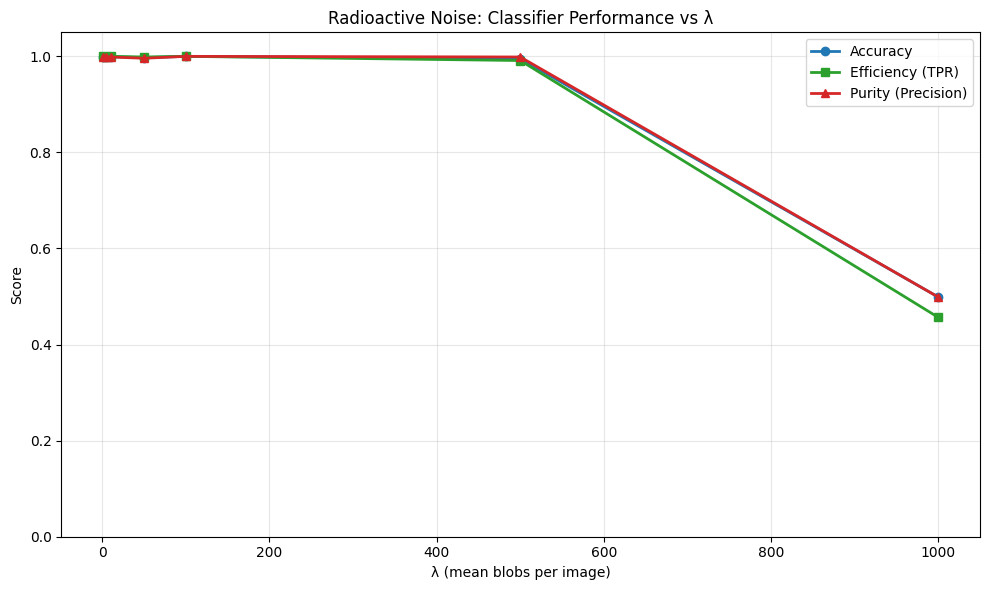

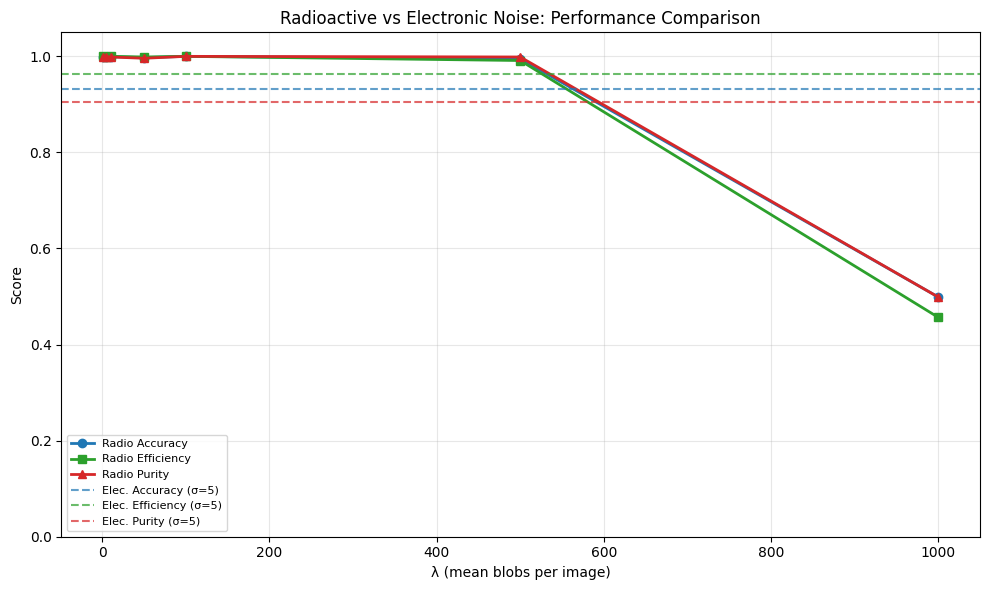

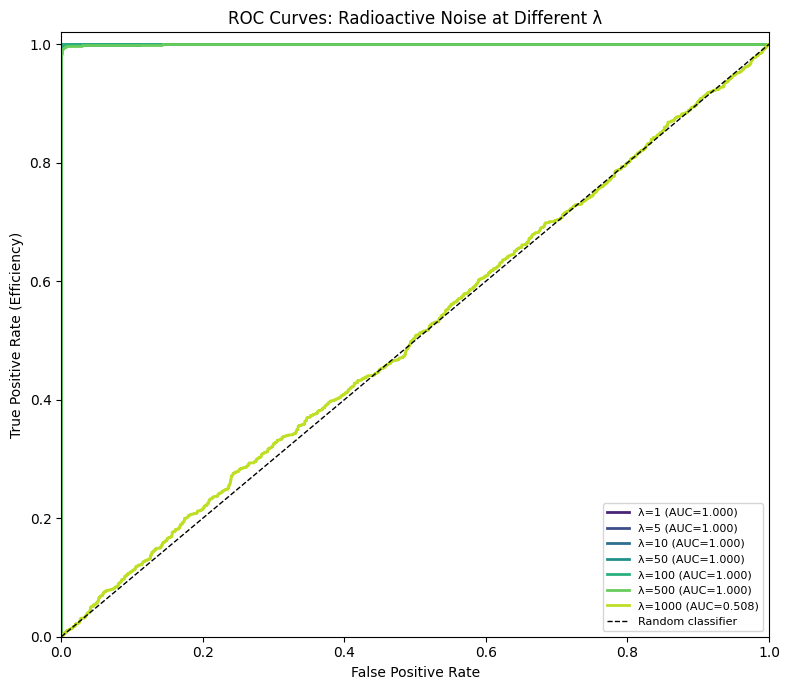

In [ ]:
# Plot 1: Accuracy, Efficiency, Purity vs lambda
lams = list(radio_results.keys())
accs = [radio_results[l]['acc'] for l in lams]
effs = [radio_results[l]['efficiency'] for l in lams]
purs = [radio_results[l]['purity'] for l in lams]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lams, accs, 'o-', color='tab:blue', label='Accuracy', linewidth=2, markersize=6)
ax.plot(lams, effs, 's-', color='tab:green', label='Efficiency (TPR)', linewidth=2, markersize=6)
ax.plot(lams, purs, '^-', color='tab:red', label='Purity (Precision)', linewidth=2, markersize=6)
ax.set_xlabel('\u03bb (mean blobs per image)')
ax.set_ylabel('Score')
ax.set_title('Radioactive Noise: Classifier Performance vs \u03bb')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('./figures/radio_performance_vs_lam.png', dpi=200)
plt.show()

# Plot 2: Comparison with electronic noise best
elec_best = results[(best_avg_sigma, best_avg_sigma)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lams, accs, 'o-', color='tab:blue', label='Radio Accuracy', linewidth=2, markersize=6)
ax.plot(lams, effs, 's-', color='tab:green', label='Radio Efficiency', linewidth=2, markersize=6)
ax.plot(lams, purs, '^-', color='tab:red', label='Radio Purity', linewidth=2, markersize=6)

# Horizontal dashed lines for electronic noise best
ax.axhline(elec_best['acc'], color='tab:blue', linestyle='--', alpha=0.7,
           label=f'Elec. Accuracy (\u03c3={best_avg_sigma})')
ax.axhline(elec_best['efficiency'], color='tab:green', linestyle='--', alpha=0.7,
           label=f'Elec. Efficiency (\u03c3={best_avg_sigma})')
ax.axhline(elec_best['purity'], color='tab:red', linestyle='--', alpha=0.7,
           label=f'Elec. Purity (\u03c3={best_avg_sigma})')

ax.set_xlabel('\u03bb (mean blobs per image)')
ax.set_ylabel('Score')
ax.set_title('Radioactive vs Electronic Noise: Performance Comparison')
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('./figures/radio_vs_electronic_comparison.png', dpi=200)
plt.show()

# Plot 3: ROC curves at different lambda values
fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(lams)))

for i, lam in enumerate(lams):
    res = radio_results[lam]
    ax.plot(res['fpr_arr'], res['tpr_arr'], color=colors[i], lw=2,
            label=f'\u03bb={lam} (AUC={res["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Efficiency)')
ax.set_title('ROC Curves: Radioactive Noise at Different \u03bb')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('./figures/radio_roc_curves.png', dpi=200)
plt.show()

### Discussion: Radioactive and Electronic Noise

At low to moderate blob densities (λ $\le$ 500), the classifier achieves near-perfect
performance (accuracy $\ge$ 0.995, AUC = 1.000), substantially exceeding the
electronic noise baseline (accuracy is around 0.84 at σ = 5). This is attributable to the
spatial sparsity of radioactive blobs. They are isolated, compact deposits and are readily
distinguished from the extended track structures of neutrino interactions.

The performance collapses between λ = 500 and λ = 1000, where accuracy
falls to 0.499 and AUC to 0.508, indistinguishable from random classification.
This sharp transition suggests a critical density threshold beyond which blob
overlap generates background images whose spatial complexity is no longer
separable from genuine neutrino events. Unlike electronic noise, whose failure
mode is the suppression of signal features, radioactive noise at extreme density
produces spatially structured backgrounds that directly mimic signal shape.